In [1]:
import json
import os

import pandas as pd

# Plot the accuracy

# WITHOUT BEAM MATCHING
dir = '../data/results/experiments/beam_matching_experiment'
errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])

control_errors_df = pd.read_csv(os.path.join(dir, 'control_errors.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

control_errors_df

,0
0,4.001489
1,4.142166


In [2]:
from typing import Union
import matplotlib.pyplot as plt


def make_boxplot(
        df: pd.DataFrame,
        control_df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        color: Union[str, dict] = "forestgreen",
        baseline: float = None,
        annotate: bool = False,
):
    """
    Creates a boxplot of the given dataframes.

    :param control_df: DataFrame containing control data
    :param baseline: Optional baseline value to plot
    :param df: DataFrame containing experimental data
    :param title: Plot title
    :param x_label: X-axis label
    :param y_label: Y-axis label
    :param color: Color of the boxes
    :param annotate: Whether to annotate mean values
    """
    # Prepare data by pairing control and regular columns
    data_values = []
    labels = []
    means = []
    positions = []

    # Calculate positions for paired boxes
    for i in range(len(df.columns)):
        base_pos = i * 3  # Leave more space between pairs
        positions.extend([base_pos, base_pos + 1])  # Positions for control and regular

        # Add control column
        data_values.append(control_df[df.columns[i]])
        labels.append(str(i))  # Just the number
        means.append(control_df[df.columns[i]].mean())

        # Add regular column
        data_values.append(df[df.columns[i]])
        labels.append(str(i))  # Same number for the pair
        means.append(df[df.columns[i]].mean())

    num_boxes = len(data_values)

    plt.figure(figsize=(20, 12))
    median_props = dict(color="black", linewidth="3")
    plot = plt.boxplot(
        data_values,
        positions=positions,  # Use custom positions
        patch_artist=True,
        medianprops=median_props,
    )

    # Handle color and hatch assignment
    legend_elements = []
    for i, patch in enumerate(plot["boxes"]):
        if i % 2 == 0:  # Control boxes
            patch.set_facecolor("lightblue")
            patch.set_hatch('/')
            if i == 0:  # Only add to legend once
                legend_elements.append(patch)
        else:  # Regular boxes
            patch.set_facecolor(color if isinstance(color, str) else color.get(labels[i], "forestgreen"))
            patch.set_hatch('\\')
            if i == 1:  # Only add to legend once
                legend_elements.append(patch)

    # Add legend
    plt.legend(legend_elements, ['Without beam matching', 'With beam matching'], loc='upper right')

    if baseline:
        plt.axhline(
            y=baseline,
            color="red",
            linestyle="-",
            linewidth=2,
            label="Baseline",
        )

    if annotate:
        text_offset = 0.22 if num_boxes < 4 else 0.4
        for i, mean in enumerate(means, 1):
            plt.text(
                i + text_offset,
                mean,
                f"\n{mean:.2f}",
                horizontalalignment="right",
                verticalalignment="center",
                color="black",
            )

    # formatting the plot
    plt.title(title)
    plt.grid(axis="y")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.margins(x=0.1)

    # Set x-ticks at the center of each pair
    tick_positions = [pos + 0.5 for pos in positions[::2]]  # Center between each pair
    plt.xticks(tick_positions, [str(i) for i in range(len(df.columns))])

    # Show the plot
    plt.show()




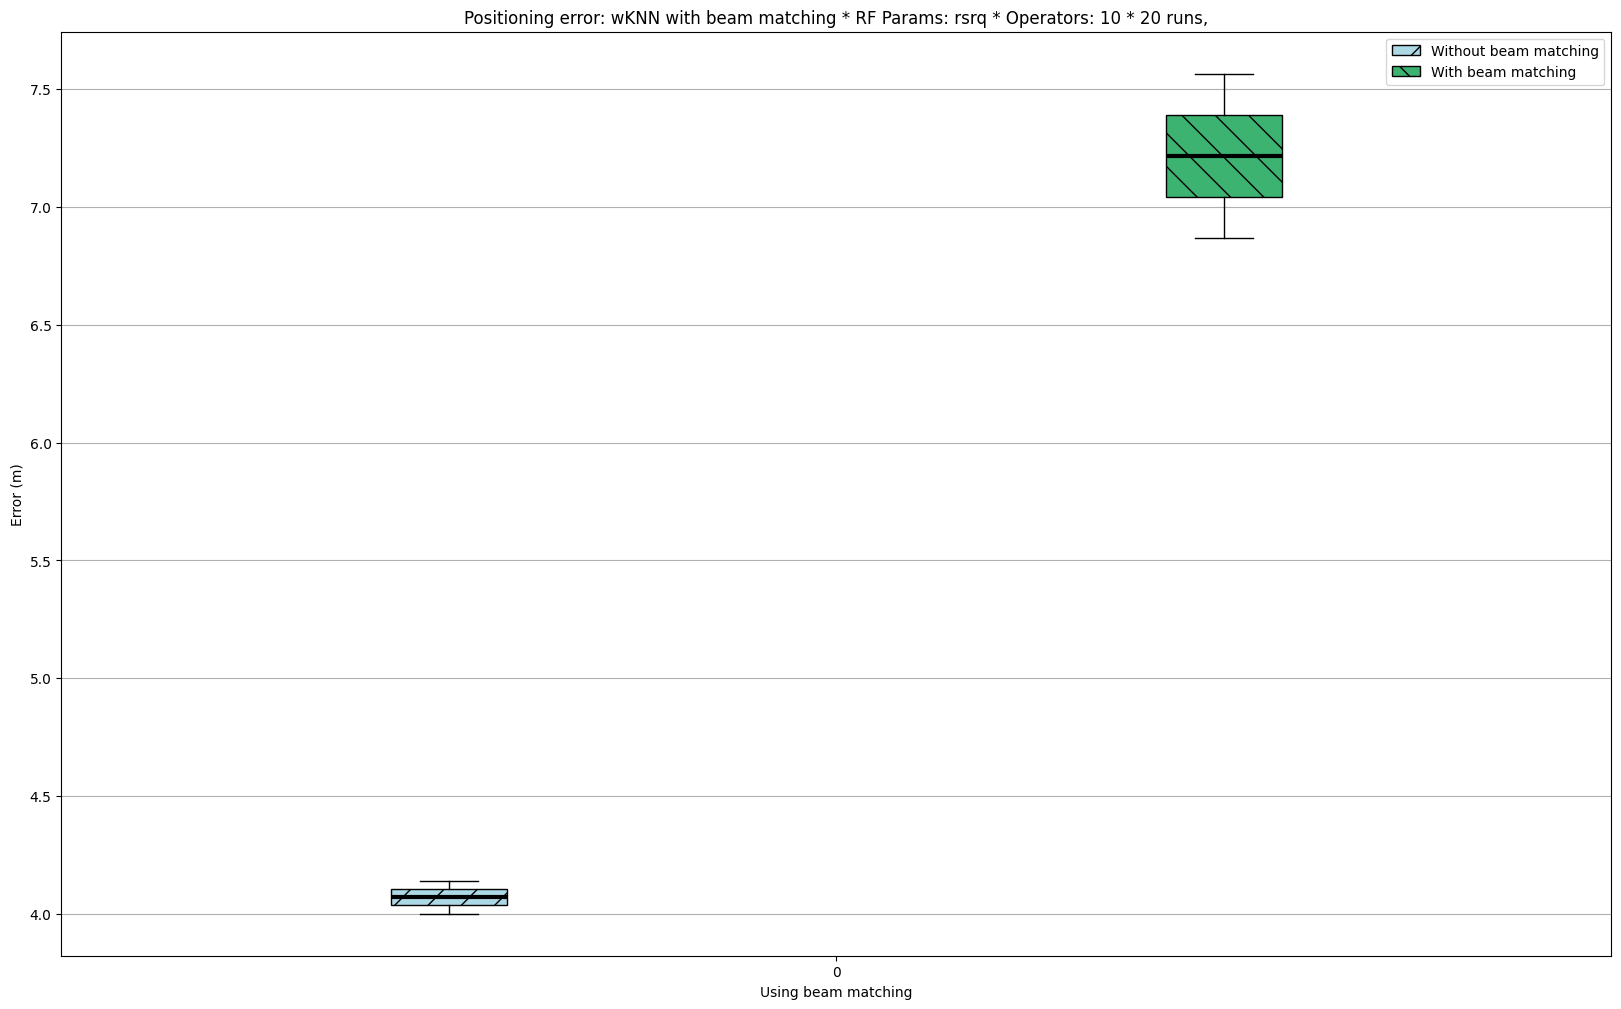

In [3]:

from scripts.utils import operators_to_str

param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'

title_string = f'wKNN with beam matching * {param_str} * {operator_str} * {config["n_runs"]} runs,'

make_boxplot(
    df=errors_df,
    control_df=control_errors_df,
    title=f'Positioning error: {title_string}',
    x_label='Using beam matching',
    y_label='Error (m)',
    color='mediumseagreen',
)
